In [1]:
#TASK3 CODE1

In [2]:
import pandas as pd

In [3]:
from sklearn.datasets import load_iris

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
import warnings

In [7]:
warnings.filterwarnings("ignore")

In [31]:
iris_raw = load_iris()
X_iris = iris_raw.data
y_iris = iris_raw.target

In [33]:
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris_scaled, y_iris, test_size=0.20, stratify=y_iris, random_state=42
)

In [37]:
print("Training set shape:", X_train.shape)

Training set shape: (120, 4)


In [14]:
print("Test set shape:", X_test.shape)

Test set shape: (30, 4)


In [39]:
#TASK1 CODE2

In [8]:
from sklearn.linear_model import LogisticRegression

In [9]:
from sklearn.metrics import accuracy_score

In [69]:
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)
lr_model.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial', random_state=42)

In [71]:
lr_preds = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_preds)

In [73]:
print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Test Accuracy: 93.33%


In [75]:
#TASK1 CODE3

In [77]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [79]:
lda_model = LinearDiscriminantAnalysis()

In [81]:
lda_model.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [83]:
lda_preds = lda_model.predict(X_test)

In [85]:
lda_accuracy = accuracy_score(y_test, lda_preds)

In [27]:
print(f"LDA Test Accuracy: {lda_accuracy * 100:.2f}%")

LDA Test Accuracy: 100.00%


In [87]:
#TASK1 CODE4

In [127]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [129]:
knn = KNeighborsClassifier()

In [131]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [133]:
y_pred_knn = knn.predict(X_test)

In [135]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

In [141]:
print("k-NN Classification Accuracy:", knn_accuracy)

k-NN Classification Accuracy: 0.9333333333333333


In [143]:
#TASK1 CODE5

In [145]:
comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)'
    ],

    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100
    ]
})

In [147]:
print("--- Performance Comparison on Iris Dataset ---")

--- Performance Comparison on Iris Dataset ---


In [38]:
print(comparison_df.to_string(index=False))

             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          93.333333
Linear Discriminant Analysis (LDA)         100.000000
        k-Nearest Neighbors (k-NN)          93.333333


In [149]:
#TASK2 CODE1

In [151]:
import pandas as pd

In [153]:
from sklearn.model_selection import train_test_split

In [155]:
from sklearn.preprocessing import StandardScaler

In [157]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [159]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [161]:
sonar_columns = sonar_features + ['Class']

In [163]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [165]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [167]:
X_sonar = sonar_df[sonar_features]

In [169]:
y_sonar = sonar_df['Class_numeric']

In [171]:
scaler_sonar = StandardScaler()

In [173]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [175]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [177]:
print("Sonar Training Set Shape:", X_train_s.shape)

Sonar Training Set Shape: (145, 60)


In [181]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


In [183]:
#TASK2 CODE2

In [185]:
from sklearn.naive_bayes import GaussianNB

In [187]:
from sklearn.metrics import accuracy_score

In [189]:
nb_model = GaussianNB()

In [191]:
nb_model.fit(X_train_s, y_train_s)

GaussianNB()

In [193]:
nb_preds = nb_model.predict(X_test_s)

In [195]:
nb_accuracy = accuracy_score(y_test_s, nb_preds)

In [197]:
print(f"Gaussian Naïve Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")

Gaussian Naïve Bayes Test Accuracy: 76.19%


In [199]:
#TASK3 CODE3

In [201]:
from sklearn.svm import SVC

In [203]:
svm_linear = SVC(kernel='linear', probability=True, random_state=42)

In [205]:
svm_linear.fit(X_train_s, y_train_s)

SVC(kernel='linear', probability=True, random_state=42)

In [209]:
linear_preds = svm_linear.predict(X_test_s)

In [211]:
linear_accuracy = accuracy_score(y_test_s, linear_preds)

In [213]:
print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy * 100:.2f}%")

Linear Kernel SVM Test Accuracy: 79.37%


In [67]:
sonar_comparison = pd.DataFrame({
    'Classifier': ['Gaussian Naïve Bayes (Probabilistic)', 'Linear Kernel SVM (Maximum-Margin)'],
    'Test Accuracy (%)': [nb_accuracy * 100, linear_accuracy * 100]
})

In [68]:
print("--- Performance Comparison on High-Dimensional Sonar Dataset ---")

--- Performance Comparison on High-Dimensional Sonar Dataset ---


In [69]:
print(sonar_comparison.to_string(index=False))

                          Classifier  Test Accuracy (%)
Gaussian Naïve Bayes (Probabilistic)          76.190476
  Linear Kernel SVM (Maximum-Margin)          79.365079


In [215]:
#TASK3 CODE1

In [217]:
import matplotlib.pyplot as plt

In [219]:
import seaborn as sns

In [221]:
from sklearn.metrics import confusion_matrix

In [223]:
cm = confusion_matrix(y_test, lr_preds)

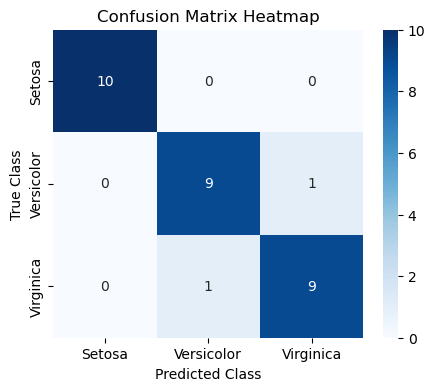

In [327]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.title("Confusion Matrix Heatmap")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [235]:
#TASK3 CODE2

In [237]:
from sklearn.metrics import classification_report

In [239]:
report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Setosa', 'Versicolor', 'Virginica']
)

In [241]:
print("--- Logistic Regression Classification Report ---")

--- Logistic Regression Classification Report ---


In [243]:
print(report_output)

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [245]:
from sklearn.preprocessing import label_binarize

In [247]:
from sklearn.metrics import roc_curve, auc

In [249]:
import matplotlib.pyplot as plt

In [251]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

In [253]:
y_score = lr_model.predict_proba(X_test)

In [255]:
plt.figure(figsize=(7,6))

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

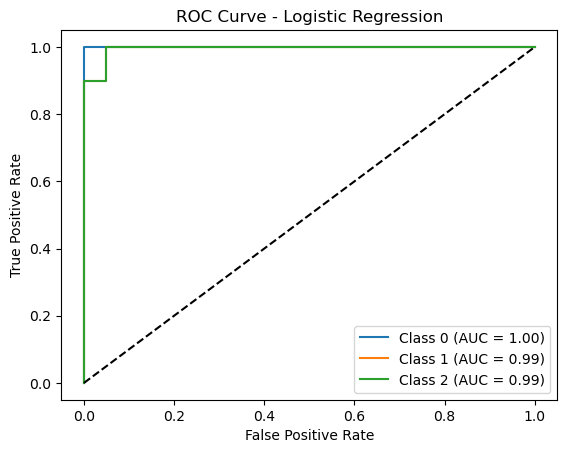

In [293]:
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

In [295]:
from sklearn.datasets import load_iris

In [297]:
from sklearn.preprocessing import StandardScaler

In [299]:
from sklearn.linear_model import LogisticRegression

In [301]:
from sklearn.model_selection import cross_val_score

In [303]:
import numpy as np

In [305]:
iris = load_iris()

In [307]:
X = iris.data

In [309]:
y = iris.target

In [311]:
scaler = StandardScaler()

In [313]:
X_scaled = scaler.fit_transform(X)

In [315]:
lr_model = LogisticRegression(max_iter=200)

In [317]:
cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

In [319]:
print("5-Fold Cross-Validation Accuracy:")

5-Fold Cross-Validation Accuracy:


In [321]:
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

Fold 1: 0.9667
Fold 2: 1.0000
Fold 3: 0.9333
Fold 4: 0.9000
Fold 5: 1.0000


In [323]:
print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))


Mean Accuracy: 96.00%


In [325]:
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))

Standard Deviation: 3.89%


In [2]:
#postlab

In [12]:
import pandas as pd

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [15]:
import warnings

In [16]:
warnings.filterwarnings("ignore")

In [17]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

In [19]:
titanic = pd.read_csv(url)

In [20]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [23]:
titanic["Age"].fillna(titanic["Age"].median(), inplace=True)

In [24]:
titanic["Embarked"].fillna(titanic["Embarked"].mode()[0], inplace=True)

In [25]:
titanic.drop("Cabin", axis=1, inplace=True)

In [26]:
titanic["Sex"] = LabelEncoder().fit_transform(titanic["Sex"])

In [27]:
titanic["Embarked"] = LabelEncoder().fit_transform(titanic["Embarked"])

In [28]:
X = titanic.drop(["PassengerId","Name","Ticket","Survived"], axis=1)

In [29]:
y = titanic["Survived"]

In [30]:
scaler = StandardScaler()

In [31]:
X_scaled = scaler.fit_transform(X)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [33]:
print("Training set shape:", X_train.shape)

Training set shape: (712, 7)


In [34]:
print("Test set shape:", X_test.shape)

Test set shape: (179, 7)


In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
from sklearn.metrics import accuracy_score

In [37]:
lr_model = LogisticRegression(random_state=42)

In [38]:
lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [39]:
lr_preds = lr_model.predict(X_test)

In [40]:
lr_accuracy = accuracy_score(y_test, lr_preds)

In [41]:
print(f"Logistic Regression Test Accuracy: {lr_accuracy*100:.2f}%")

Logistic Regression Test Accuracy: 79.89%


In [42]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


In [43]:
lda_model = LinearDiscriminantAnalysis()

In [44]:
lda_model.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [45]:
lda_preds = lda_model.predict(X_test)

In [47]:
lda_accuracy = accuracy_score(y_test, lda_preds)

In [48]:
print(f"LDA Test Accuracy: {lda_accuracy*100:.2f}%")

LDA Test Accuracy: 79.33%


In [49]:
from sklearn.neighbors import KNeighborsClassifier

In [50]:
from sklearn.metrics import classification_report, confusion_matrix

In [51]:
knn = KNeighborsClassifier()

In [52]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [53]:
y_pred_knn = knn.predict(X_test)

In [54]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

In [55]:
print(f"k-NN Classification Accuracy: {knn_accuracy*100:.2f}%")

k-NN Classification Accuracy: 81.56%


In [56]:
comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy*100,
        lda_accuracy*100,
        knn_accuracy*100
    ]
})

print("--- Performance Comparison on Titanic Dataset ---")

print(comparison_df.to_string(index=False))


--- Performance Comparison on Titanic Dataset ---
             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          79.888268
Linear Discriminant Analysis (LDA)          79.329609
        k-Nearest Neighbors (k-NN)          81.564246


In [57]:
titanic_df = pd.read_csv(url)


In [58]:
titanic_df["Age"].fillna(titanic_df["Age"].median(), inplace=True)

In [59]:
titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0], inplace=True)

In [60]:
titanic_df.drop("Cabin", axis=1, inplace=True)

In [61]:
titanic_df["Sex"] = LabelEncoder().fit_transform(titanic_df["Sex"])

In [62]:
titanic_df["Embarked"] = LabelEncoder().fit_transform(titanic_df["Embarked"])

In [63]:
X_titanic = titanic_df.drop(["PassengerId","Name","Ticket","Survived"], axis=1)

In [64]:
y_titanic = titanic_df["Survived"]

In [65]:
scaler_titanic = StandardScaler()

In [66]:
X_titanic_scaled = scaler_titanic.fit_transform(X_titanic)

In [67]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_titanic_scaled,
    y_titanic,
    test_size=0.30,
    stratify=y_titanic,
    random_state=42
)

In [68]:
print("Titanic Training Set Shape:", X_train_s.shape)

Titanic Training Set Shape: (623, 7)


In [69]:
print("Titanic Test Set Shape:", X_test_s.shape)

Titanic Test Set Shape: (268, 7)


In [70]:
from sklearn.naive_bayes import GaussianNB

In [71]:
nb_model = GaussianNB()

In [72]:
nb_model.fit(X_train_s, y_train_s)

GaussianNB()

In [73]:
nb_preds = nb_model.predict(X_test_s)

In [74]:
nb_accuracy = accuracy_score(y_test_s, nb_preds)

In [75]:
print(f"Gaussian Naïve Bayes Test Accuracy: {nb_accuracy*100:.2f}%")

Gaussian Naïve Bayes Test Accuracy: 79.10%


In [76]:
from sklearn.svm import SVC

In [77]:
svm_linear = SVC(kernel='linear', probability=True, random_state=42)

In [78]:
svm_linear.fit(X_train_s, y_train_s)

SVC(kernel='linear', probability=True, random_state=42)

In [79]:
linear_preds = svm_linear.predict(X_test_s)

In [80]:
linear_accuracy = accuracy_score(y_test_s, linear_preds)

In [81]:
print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy*100:.2f}%")

Linear Kernel SVM Test Accuracy: 77.61%


In [82]:
sonar_comparison = pd.DataFrame({
    'Classifier': [
        'Gaussian Naïve Bayes (Probabilistic)',
        'Linear Kernel SVM (Maximum-Margin)'
    ],
    'Test Accuracy (%)': [
        nb_accuracy*100,
        linear_accuracy*100
    ]
})

print("--- Performance Comparison on Titanic Dataset ---")

print(sonar_comparison.to_string(index=False))

--- Performance Comparison on Titanic Dataset ---
                          Classifier  Test Accuracy (%)
Gaussian Naïve Bayes (Probabilistic)          79.104478
  Linear Kernel SVM (Maximum-Margin)          77.611940


In [83]:
from sklearn.metrics import classification_report

In [84]:
report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Not Survived','Survived']
)

print(report_output)

              precision    recall  f1-score   support

Not Survived       0.81      0.88      0.84       110
    Survived       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



In [85]:
import matplotlib.pyplot as plt

In [86]:
import seaborn as sns

In [87]:
from sklearn.metrics import confusion_matrix

In [88]:
cm = confusion_matrix(y_test, lr_preds)

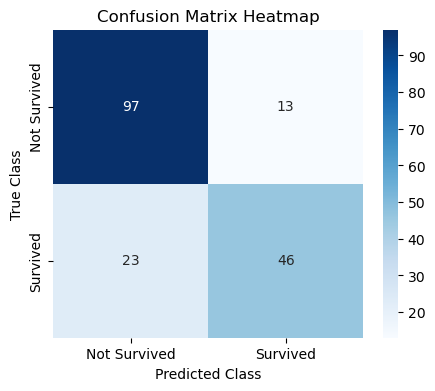

In [89]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived','Survived'],
    yticklabels=['Not Survived','Survived']
)

plt.title("Confusion Matrix Heatmap")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [90]:
from sklearn.metrics import roc_curve, auc

In [91]:
y_score = lr_model.predict_proba(X_test)[:,1]

In [92]:
fpr, tpr, _ = roc_curve(y_test, y_score)

In [93]:
roc_auc = auc(fpr, tpr)

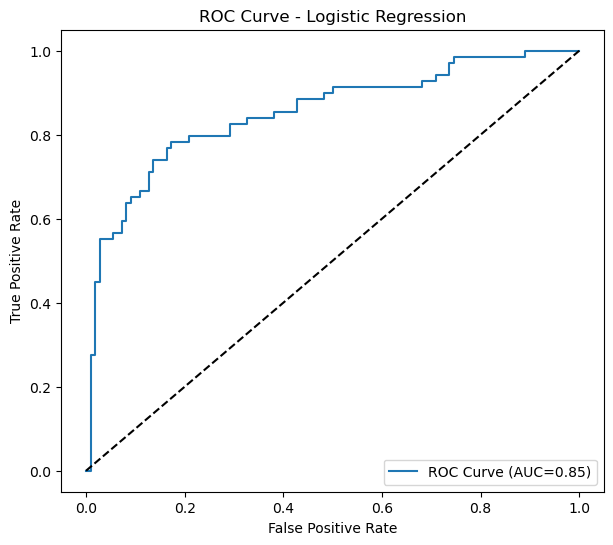

In [94]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

In [95]:
from sklearn.model_selection import cross_val_score

In [96]:
import numpy as np

In [97]:
lr_model = LogisticRegression(random_state=42)

In [98]:
cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

In [99]:
print("5-Fold Cross-Validation Accuracy:")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores)*100))

print("Standard Deviation: {:.2f}%".format(np.std(cv_scores)*100))

5-Fold Cross-Validation Accuracy:
Fold 1: 0.7709
Fold 2: 0.7865
Fold 3: 0.7809
Fold 4: 0.7640
Fold 5: 0.8202

Mean Accuracy: 78.45%
Standard Deviation: 1.95%
